In [29]:
# Install required packages (run once).
# If you're running in a managed environment that disallows !pip, install packages manually.
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost statsmodels plotly joblib scikit-optimize prophet || true


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [30]:
# Imports
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import plotly.express as px
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
try:
    from prophet import Prophet
    HAS_PROPHET = True
except Exception:
    HAS_PROPHET = False
import statsmodels.api as sm

## Preprocessing & Feature Engineering (split cells)

We'll: median-impute numeric features, fill categorical missing values with 'Unknown', create time features and lag features (1,3,6,12), and build a preprocessing pipeline with One-Hot encoding.

In [31]:
# Preprocessing - setup, df copy, add time features and lags
from sklearn.impute import SimpleImputer
# Copy dataframe to avoid mutating original
df_fe = df.copy()
# Add time features if date exists
if 'date' in df_fe.columns:
    df_fe['year'] = df_fe['date'].dt.year
    df_fe['month'] = df_fe['date'].dt.month
    df_fe['day'] = df_fe['date'].dt.day
    df_fe['dayofweek'] = df_fe['date'].dt.dayofweek
    df_fe['quarter'] = df_fe['date'].dt.quarter
    print('Added time features: year, month, day, dayofweek, quarter')
else:
    print('No date column; skipping time feature creation')
# Default lags to create (months)
lags = [1, 3, 6, 12]
if TARGET is None:
    raise ValueError('No TARGET detected. Set TARGET manually before preprocessing.')
# Create lag and rolling mean features based on global time ordering
if 'date' in df_fe.columns:
    df_fe = df_fe.sort_values('date').reset_index(drop=True)
    for l in lags:
        df_fe[f'lag_{l}'] = df_fe[TARGET].shift(l)
        df_fe[f'roll_mean_{l}'] = df_fe[TARGET].shift(1).rolling(window=l).mean()
    print('Created lag and rolling features:', [f'lag_{l}' for l in lags])
else:
    print('No date column - cannot create time lags')

Added time features: year, month, day, dayofweek, quarter
Created lag and rolling features: ['lag_1', 'lag_3', 'lag_6', 'lag_12']


In [32]:
# Feature selection and cleaning (drop rows with missing target/lag features)
exclude = [TARGET, 'date'] if 'date' in df_fe.columns else [TARGET]
numeric_features = [c for c in df_fe.select_dtypes(include=[np.number]).columns.tolist() if c not in exclude]
categorical_features = [c for c in df_fe.columns if df_fe[c].dtype == 'object' and c not in exclude]
print('Numeric features for pipeline:', numeric_features)
print('Categorical features for pipeline:', categorical_features)
# Drop rows with missing TARGET (models need target)
df_fe = df_fe.dropna(subset=[TARGET]).reset_index(drop=True)
# Drop rows with NaNs in any lag cols to avoid leakage
lag_cols = [c for c in df_fe.columns if c.startswith('lag_') or c.startswith('roll_mean_')]
if lag_cols:
    before_len = len(df_fe)
    df_fe = df_fe.dropna(subset=lag_cols).reset_index(drop=True)
    print(f'Dropped {before_len - len(df_fe)} rows with NA in lag features')
# Final feature list
feature_cols = numeric_features + categorical_features
print('Total features to use in pipeline:', len(feature_cols))

Numeric features for pipeline: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'year', 'month', 'day', 'dayofweek', 'quarter', 'lag_1', 'roll_mean_1', 'lag_3', 'roll_mean_3', 'lag_6', 'roll_mean_6', 'lag_12', 'roll_mean_12']
Categorical features for pipeline: []
Dropped 12 rows with NA in lag features
Total features to use in pipeline: 21


In [33]:
# Build ColumnTransformer and model pipelines
# Numeric pipeline: median imputation + scaling
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),('ohe', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])
# Define pipelines
lr_pipe = Pipeline(steps=[('pre', preprocessor), ('model', LinearRegression())])
rf_pipe = Pipeline(steps=[('pre', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
models = {'lr': lr_pipe, 'rf': rf_pipe}
if HAS_XGB:
    from xgboost import XGBRegressor
    xgb_pipe = Pipeline(steps=[('pre', preprocessor), ('model', XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42))])
    models['xgb'] = xgb_pipe
print('Configured model pipelines:', list(models.keys()))

Configured model pipelines: ['lr', 'rf', 'xgb']


In [34]:
# Prepare train/test split (time-aware if date exists) and create X/y
df_model = df_fe.copy()
if 'date' in df_model.columns:
    df_model = df_model.sort_values('date').reset_index(drop=True)
    split_idx = int(len(df_model) * 0.8)
    train_df = df_model.iloc[:split_idx].copy()
    test_df = df_model.iloc[split_idx:].copy()
else:
    train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42)
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET].copy()
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (2102, 21) Test shape: (526, 21)


In [35]:
# Baseline training loop (MAE, RMSE, R2). RMSE computed compatibly across sklearn versions
import math
results = {}
for name, pipe in models.items():
    print('Training', name)
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = math.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {'mae': mae, 'rmse': rmse, 'r2': r2, 'model': pipe}
    print(f"{name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")
print('Baseline training complete')

Training lr
lr -> MAE: 322.438, RMSE: 391.242, R2: 0.989
Training rf
rf -> MAE: 338.262, RMSE: 422.698, R2: 0.987
Training xgb
rf -> MAE: 338.262, RMSE: 422.698, R2: 0.987
Training xgb
xgb -> MAE: 279.275, RMSE: 356.543, R2: 0.990
Baseline training complete
xgb -> MAE: 279.275, RMSE: 356.543, R2: 0.990
Baseline training complete


In [36]:
# Hyperparameter tuning (RandomizedSearchCV) and save best model
from scipy.stats import randint
import math
param_dist = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(3, 20),
    'model__min_samples_split': randint(2, 10)
}
# Use rf_pipe for tuning
rs = RandomizedSearchCV(rf_pipe, param_distributions=param_dist, n_iter=20, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)
print('Best RF params:', rs.best_params_)
best_rf = rs.best_estimator_
preds = best_rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, preds)
rf_rmse = math.sqrt(mean_squared_error(y_test, preds))
rf_r2 = r2_score(y_test, preds)
print('RF tuned -> MAE:', rf_mae, 'RMSE:', rf_rmse, 'R2:', rf_r2)
results['rf_tuned'] = {'mae': rf_mae, 'rmse': rf_rmse, 'r2': rf_r2, 'model': best_rf}
# Optional XGBoost tuning
if 'xgb' in models:
    xgb_pipe = models['xgb']
    param_xgb = {
        'model__n_estimators': randint(50, 300),
        'model__max_depth': randint(3, 12)
    }
    rs_x = RandomizedSearchCV(xgb_pipe, param_distributions=param_xgb, n_iter=10, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
    rs_x.fit(X_train, y_train)
    print('Best XGB params:', rs_x.best_params_)
    best_xgb = rs_x.best_estimator_
    preds_x = best_xgb.predict(X_test)
    xgb_mae = mean_absolute_error(y_test, preds_x)
    xgb_rmse = math.sqrt(mean_squared_error(y_test, preds_x))
    xgb_r2 = r2_score(y_test, preds_x)
    print('XGB tuned -> MAE:', xgb_mae, 'RMSE:', xgb_rmse, 'R2:', xgb_r2)
    results['xgb_tuned'] = {'mae': xgb_mae, 'rmse': xgb_rmse, 'r2': xgb_r2, 'model': best_xgb}
# Save best model by RMSE
best_key = min(results.keys(), key=lambda k: results[k]['rmse'])
best_model = results[best_key]['model']
joblib.dump(best_model, 'best_pipeline.joblib')
print('Saved best pipeline as best_pipeline.joblib (key:', best_key, ')')

Best RF params: {'model__max_depth': 16, 'model__min_samples_split': 3, 'model__n_estimators': 364}
RF tuned -> MAE: 336.5017446925117 RMSE: 419.75470095351676 R2: 0.9867819889026108
Best XGB params: {'model__max_depth': 4, 'model__n_estimators': 137}
XGB tuned -> MAE: 263.7931213378906 RMSE: 335.41263066929963 R2: 0.991560161113739
Saved best pipeline as best_pipeline.joblib (key: xgb_tuned )
Best XGB params: {'model__max_depth': 4, 'model__n_estimators': 137}
XGB tuned -> MAE: 263.7931213378906 RMSE: 335.41263066929963 R2: 0.991560161113739
Saved best pipeline as best_pipeline.joblib (key: xgb_tuned )


TS rows, train: 120 test: 12
SARIMAX forecast produced


22:33:46 - cmdstanpy - INFO - Chain [1] start processing
22:33:48 - cmdstanpy - INFO - Chain [1] done processing
22:33:48 - cmdstanpy - INFO - Chain [1] done processing


Prophet failed: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")


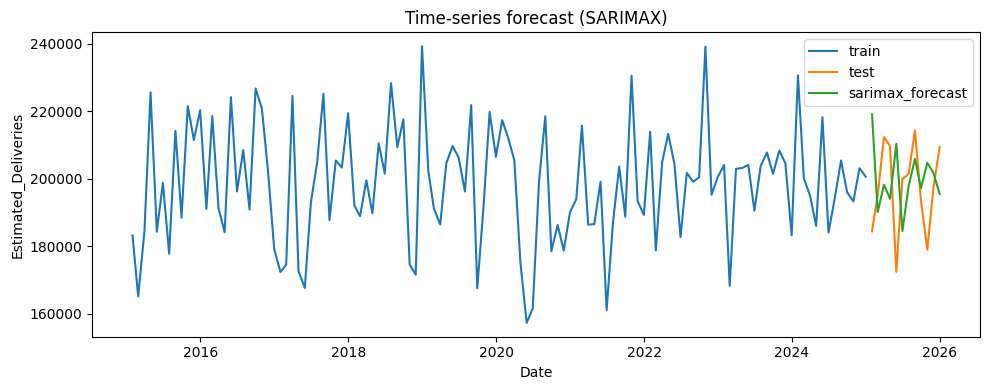

In [37]:
# Time-series forecasting (separate) - SARIMAX & Prophet fallback
if 'date' in df.columns and TARGET is not None:
    ts = df[['date', TARGET]].dropna().set_index('date').resample('ME').sum()
    ts.columns = ['y']
    n_test = min(12, len(ts) // 4)
    train_ts = ts.iloc[:-n_test] if n_test > 0 else ts
    test_ts = ts.iloc[-n_test:] if n_test > 0 else pd.DataFrame()
    print('TS rows, train:', len(train_ts), 'test:', len(test_ts))
    try:
        import statsmodels.api as sm
        model = sm.tsa.SARIMAX(train_ts['y'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        pred = res.get_forecast(steps=len(test_ts) if len(test_ts) > 0 else 12)
        pred_mean = pred.predicted_mean
        print('SARIMAX forecast produced')
    except Exception as e:
        print('SARIMAX failed:', e)
    if HAS_PROPHET:
        try:
            from prophet import Prophet
            df_prop = train_ts.reset_index().rename(columns={'date': 'ds', 'y': 'y'}) if 'date' in train_ts.reset_index().columns else train_ts.reset_index().rename(columns={train_ts.reset_index().columns[0]: 'ds', 'y': 'y'})
            m = Prophet()
            m.fit(df_prop)
            future = m.make_future_dataframe(periods=len(test_ts) if len(test_ts) > 0 else 12, freq='M')
            fc = m.predict(future)
            print('Prophet forecast produced')
        except Exception as e:
            print('Prophet failed:', e)
    try:
        plt.figure(figsize=(10, 4))
        plt.plot(train_ts.index, train_ts['y'], label='train')
        if len(test_ts) > 0:
            plt.plot(test_ts.index, test_ts['y'], label='test')
        if 'pred_mean' in locals():
            pm = pred_mean.copy()
            pm.index = pd.date_range(start=train_ts.index[-1] + pd.offsets.MonthEnd(1), periods=len(pm), freq='ME')
            plt.plot(pm.index, pm, label='sarimax_forecast')
        plt.legend()
        plt.title('Time-series forecast (SARIMAX)')
        plt.xlabel('Date')
        plt.ylabel(TARGET)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Plotting forecasts failed:', e)
else:
    print('Skipping time-series forecasting: need both date and numeric target')

In [38]:
# Auto-detect date mechanism and target column
# Many datasets provide Year and Month columns separately; we'll construct a 'date' column if present.
possible_year = [c for c in df.columns if c.lower() in ['year', 'yr']]
possible_month = [c for c in df.columns if c.lower() in ['month', 'mo']]
date_col = None
if possible_year and possible_month:
    ycol = possible_year[0]
    mcol = possible_month[0]
    df['date'] = pd.to_datetime(df[ycol].astype(int).astype(str) + '-' + df[mcol].astype(int).astype(str) + '-01', errors='coerce')
    date_col = 'date'
    print('Constructed date column from', ycol, 'and', mcol)
else:
    # attempt to find a single date-like column
    for c in df.columns:
        try:
            parsed = pd.to_datetime(df[c], errors='coerce')
            if parsed.notna().sum() > 0 and parsed.notna().sum() / len(df) > 0.5:
                df['date'] = parsed
                date_col = 'date'
                print('Parsed date column from', c)
                break
        except Exception:
            continue
if date_col is None:
    print('No date column detected; time-based features will be limited.')
# Auto-detect a sensible numeric target column
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
preferred_targets = [c for c in numeric_cols if any(k in c.lower() for k in ['deliver', 'delivery', 'deliveries', 'sales', 'price'])]
if preferred_targets:
    TARGET = preferred_targets[0]
else:
    TARGET = numeric_cols[0] if numeric_cols else None
print('Auto-detected target column:', TARGET)

Constructed date column from Year and Month
Auto-detected target column: Estimated_Deliveries


In [39]:
# Parse/sanitize date column and sort
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    missing_dates = df['date'].isna().sum()
    print('date column parsed, missing:', missing_dates)
    df = df.sort_values('date').reset_index(drop=True)
else:
    print('No date available to parse')

date column parsed, missing: 0


In [40]:
# Missing values summary
mv = df.isna().sum().sort_values(ascending=False)
print('Missing values by column (top 20):')
display(mv.head(20))
print('Total rows:', len(df))

Missing values by column (top 20):


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
date                    0
dtype: int64

Total rows: 2640


Numeric columns: ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']


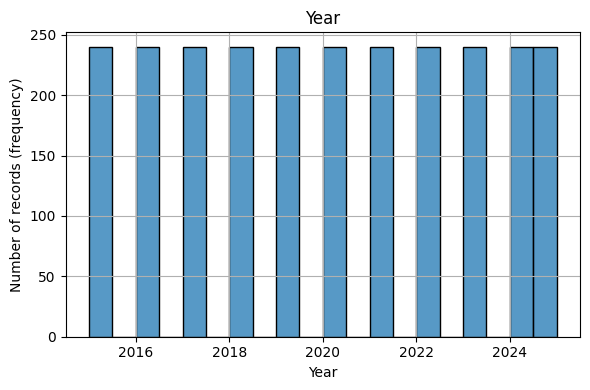

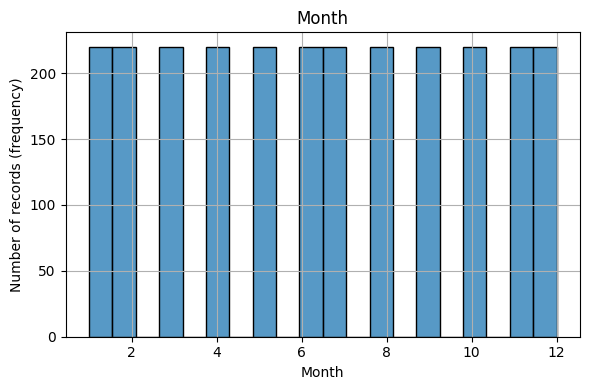

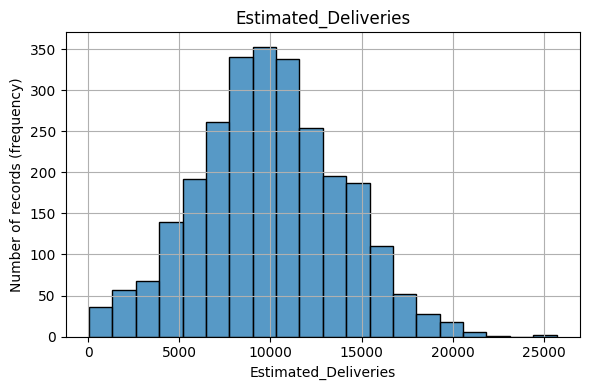

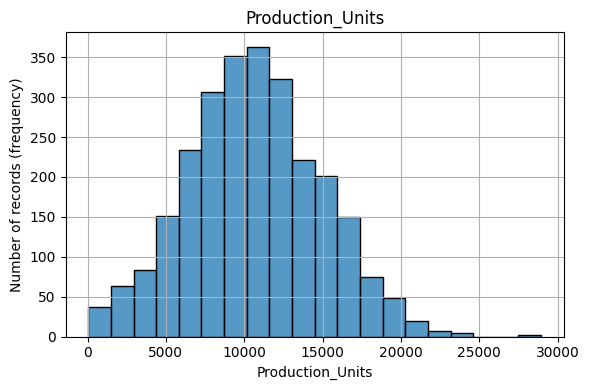

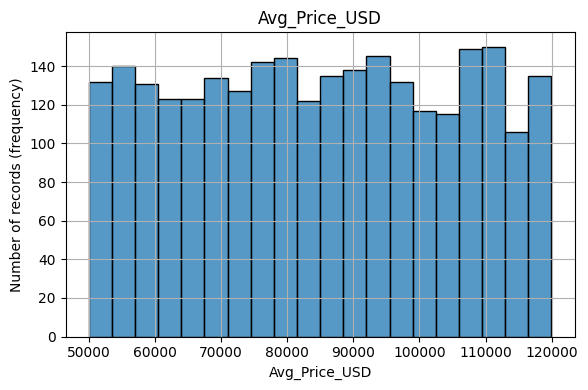

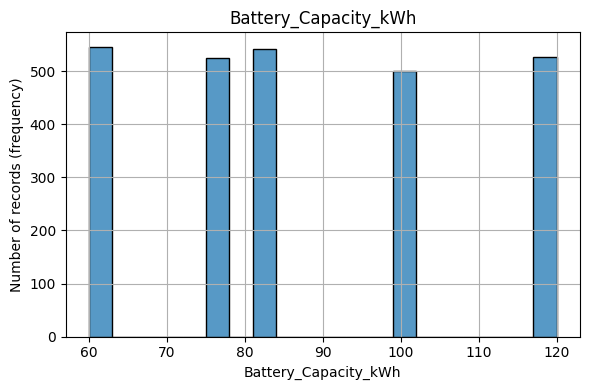

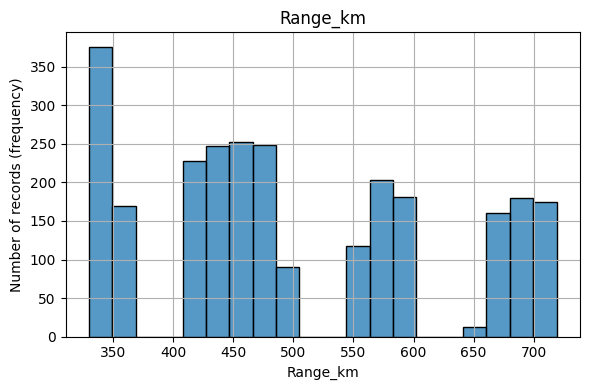

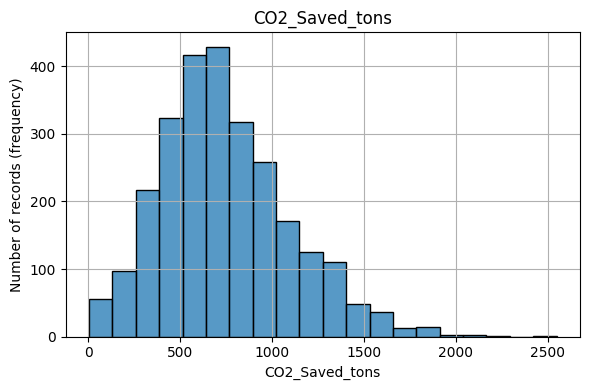

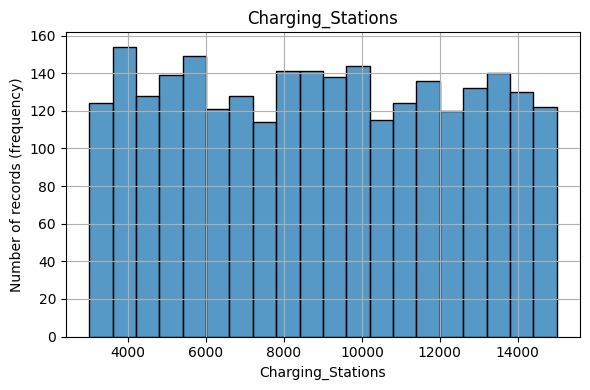

In [41]:
# Quick numeric distributions with explicit, descriptive labels
# Explanation: histogram y-axis always shows frequency (the number of records/rows that fall into each bin).
# If you want 'total counts' (e.g., total cars delivered) use aggregation (sum) over time/region instead of histogram.
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', num_cols)
# Plot each numeric column separately with descriptive labels
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), bins=20, kde=False)
    title = col
    plt.title(title)
    # X label: give a human-friendly description if available
    plt.xlabel(col)
    # Y label: frequency of records (how many rows fall into each bin). This is NOT the sum of the measured quantity.
    plt.ylabel('Number of records (frequency)')
    plt.grid(True)
    plt.tight_layout()

# Note for aggregations: if you want e.g. total deliveries per year use df.groupby('Year')['Estimated_Deliveries'].sum().plot.bar()

Monthly aggregated series length: 132


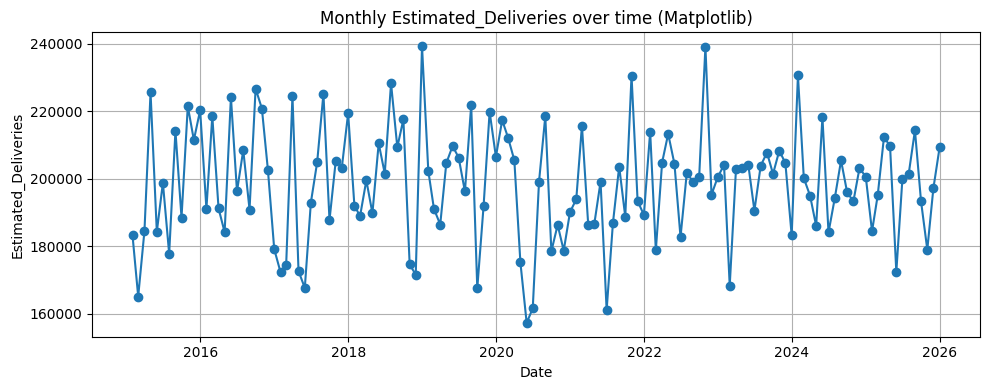

In [20]:
# Time series overview for auto-detected target (monthly aggregate) with axis labels
if TARGET is not None and 'date' in df.columns:
    # Use 'ME' (month end) offset which is supported in newer pandas versions
    ts = df[['date', TARGET]].dropna().set_index('date').resample('ME').sum()
    ts = ts.rename(columns={TARGET: 'value'})
    print('Monthly aggregated series length:', len(ts))
    
    # Provide a Matplotlib/Seaborn static plot so users in environments without Plotly/Kaleido still get a visible chart
    try:
        import matplotlib.dates as mdates
        plt.figure(figsize=(10,4))
        ts_plot = ts.copy()
        ts_plot.index = pd.to_datetime(ts_plot.index)
        plt.plot(ts_plot.index, ts_plot['value'], marker='o', linestyle='-')
        plt.title(f'Monthly {TARGET} over time (Matplotlib)')
        plt.xlabel('Date')
        plt.ylabel(TARGET)
        plt.grid(True)
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
        plt.tight_layout()
        plt.show()
    except Exception as e3:
        print('Matplotlib/Seaborn fallback failed:', e3)
else:
    print('Skipping time series plot: need both date and numeric target')

Aggregating using target: Estimated_Deliveries


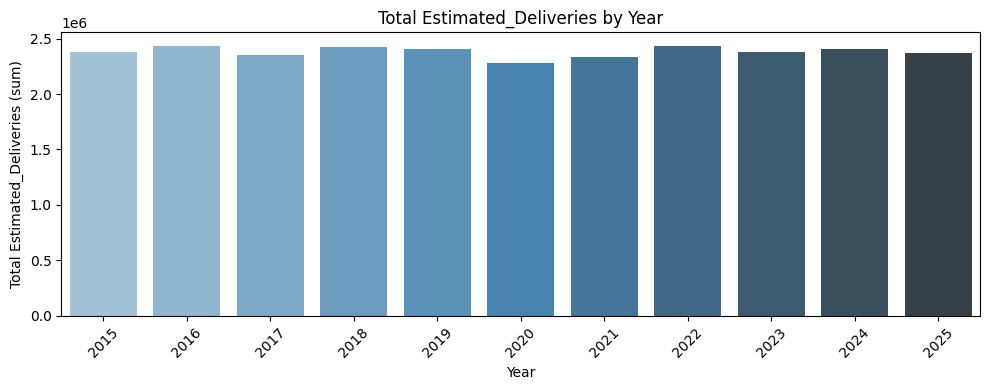

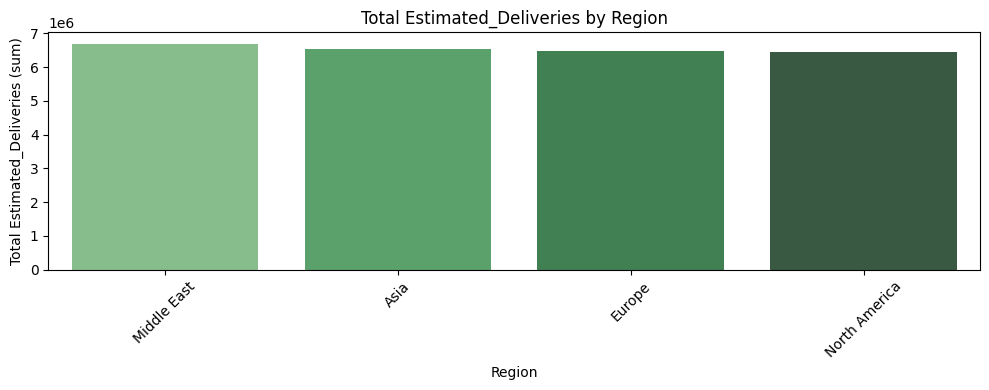

In [22]:
# Aggregated bar charts: totals per Year and per Region (clear labels)
# Choose an aggregation target: prefer 'Estimated_Deliveries' if present, else use the detected TARGET
agg_target = 'Estimated_Deliveries' if 'Estimated_Deliveries' in df.columns else TARGET
if agg_target is None:
    print('No numeric target available for aggregation.')
else:
    print('Aggregating using target:', agg_target)
    # Yearly totals if Year column exists (handles 'Year' or 'year')
    year_col = None
    for c in df.columns:
        if c.lower() == 'year':
            year_col = c
            break
    if year_col is not None:
        yearly = df.groupby(year_col)[agg_target].sum().reset_index()
        plt.figure(figsize=(10,4))
        sns.barplot(x=yearly[year_col].astype(str), y=yearly[agg_target], palette='Blues_d')
        plt.title(f'Total {agg_target} by {year_col}')
        plt.xlabel(year_col)
        plt.ylabel(f'Total {agg_target} (sum)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print('No Year column found for yearly aggregation.')
    # Region totals if Region column exists
    if 'Region' in df.columns:
        region_tot = df.groupby('Region')[agg_target].sum().sort_values(ascending=False).reset_index()
        plt.figure(figsize=(10,4))
        sns.barplot(x='Region', y=agg_target, data=region_tot, palette='Greens_d')
        plt.title(f'Total {agg_target} by Region')
        plt.xlabel('Region')
        plt.ylabel(f'Total {agg_target} (sum)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print('No Region column found for regional aggregation.')

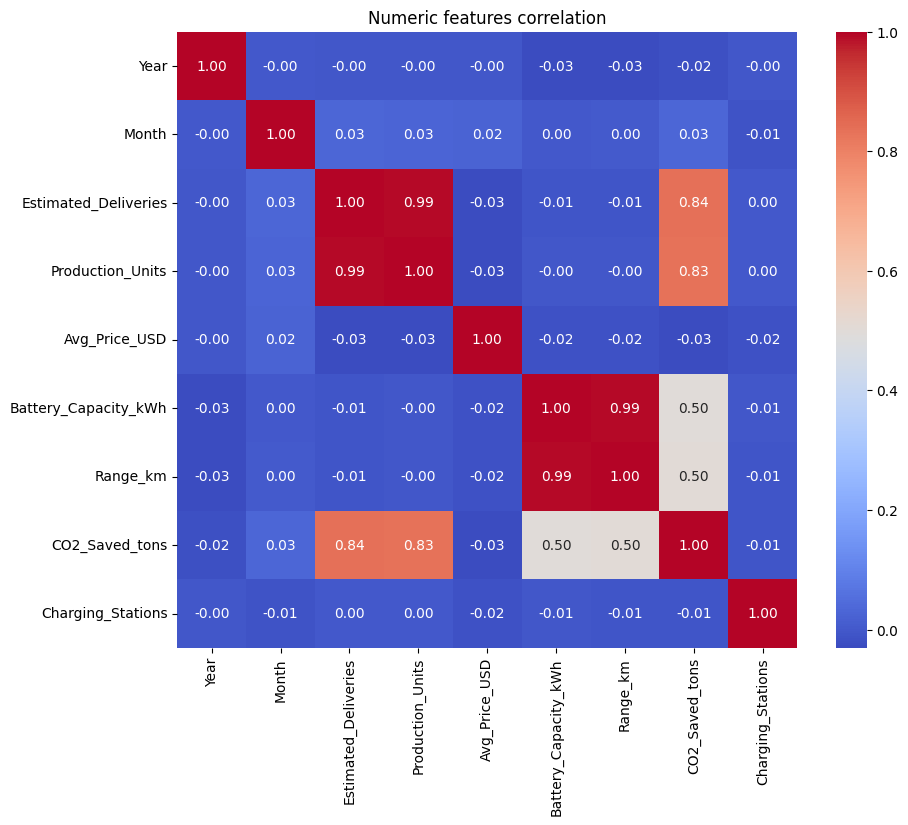

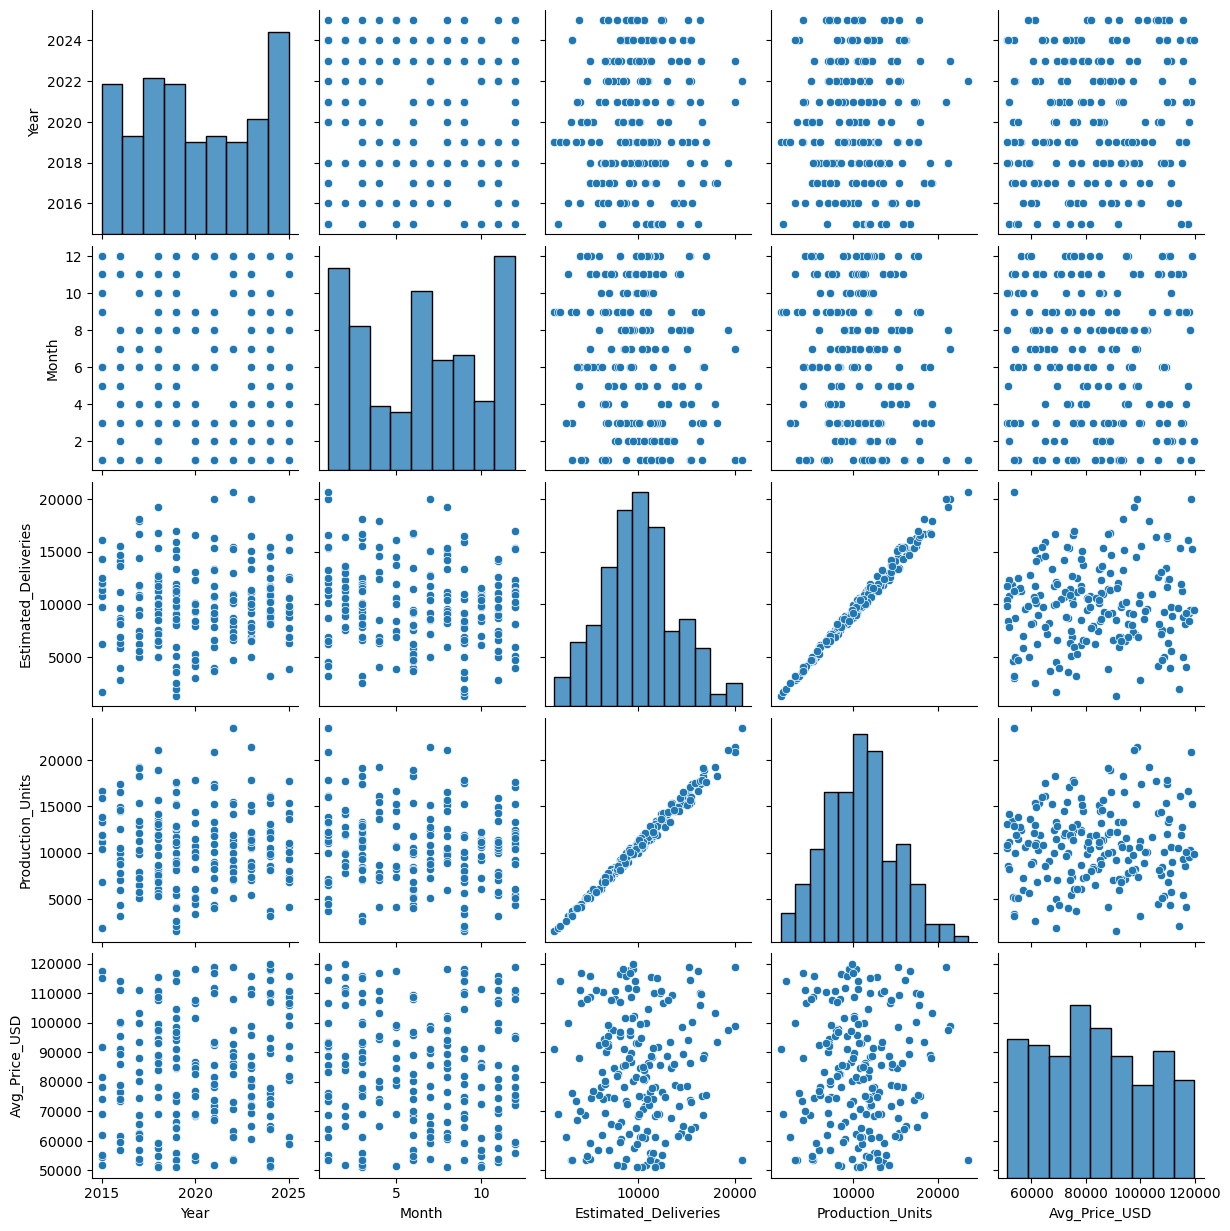

In [23]:
# Correlation heatmap (numeric features) and pairplot preview
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Numeric features correlation')
    plt.show()
    # pairplot on a subset to keep it small
    sample_cols = num_cols[:5]
    sns.pairplot(df[sample_cols].dropna().sample(min(200, len(df))))
else:
    print('Not enough numeric columns for correlation/pairplot')